# Perceptron From Scratch

In [1]:
import numpy as np

class Perceptron:

    def __init__(self, input_dim):
        self.W = np.zeros((input_dim, 1))  # Weights initialized to zero
        self.b = 0.0                        # Bias initialized to zero
        self.errors_per_epoch = []          # Track misclassifications per epoch

    @staticmethod
    def step(Z):
        """Step activation: returns 1 if Z >= 0, else 0."""
        return (Z >= 0).astype(int)

    def predict(self, X):
        """Forward pass: Z = X·W + b, output = step(Z)"""
        Z = np.dot(X, self.W) + self.b
        return self.step(Z)

    def train(self, X, y, epochs=50000, learning_rate=0.05, print_every=1000):
        m = X.shape[0]
        for epoch in range(epochs):
            predictions = self.predict(X)
            errors = y - predictions  # (m, 1): +1 if missed positive, -1 if missed negative, 0 if correct

            # Count misclassifications
            n_errors = np.sum(errors != 0)
            self.errors_per_epoch.append(n_errors)

            # Perceptron Learning Rule: update weights for every sample
            # W += lr * X^T · (y - pred) / m
            self.W += learning_rate * np.dot(X.T, errors) / m
            self.b += learning_rate * np.sum(errors) / m

            if print_every and epoch % print_every == 0:
                acc = np.mean(predictions == y)
                print(f"Epoch {epoch:>4d} | Errors: {n_errors:>4d}/{m} | Train Acc: {acc:.4f}")

## Load & Prepare Data (Perceptron)

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load the processed attrition dataset
df = pd.read_csv("../data/processed_data_attrition.csv")

# Convert standardized Attrition values back to binary (0 and 1)
attrition_vals = sorted(df["Attrition"].unique())
df["Attrition"] = df["Attrition"].map({attrition_vals[0]: 0, attrition_vals[1]: 1})

# Separate features and target
X = df.drop("Attrition", axis=1).values
y = df["Attrition"].values.reshape(-1, 1)

# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Features: {X.shape[1]}")
print(f"Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")
print(f"Attrition rate — Train: {y_train.mean():.2%} | Test: {y_test.mean():.2%}")

Features: 36
Train: 1971 samples | Test: 493 samples
Attrition rate — Train: 50.03% | Test: 49.90%


## Train the Perceptron

In [3]:
np.random.seed(42)

# Perceptron: 36 features -> 1 output (step function) — no hidden layers
perceptron = Perceptron(input_dim=X_train.shape[1])

perceptron.train(X_train, y_train, epochs=50000, learning_rate=0.05, print_every=1000)

Epoch    0 | Errors:  985/1971 | Train Acc: 0.5003
Epoch 1000 | Errors:  458/1971 | Train Acc: 0.7676
Epoch 2000 | Errors:  613/1971 | Train Acc: 0.6890
Epoch 3000 | Errors:  454/1971 | Train Acc: 0.7697
Epoch 4000 | Errors:  469/1971 | Train Acc: 0.7620
Epoch 5000 | Errors:  468/1971 | Train Acc: 0.7626
Epoch 6000 | Errors:  537/1971 | Train Acc: 0.7275
Epoch 7000 | Errors:  652/1971 | Train Acc: 0.6692
Epoch 8000 | Errors:  560/1971 | Train Acc: 0.7159
Epoch 9000 | Errors:  436/1971 | Train Acc: 0.7788
Epoch 10000 | Errors:  620/1971 | Train Acc: 0.6854
Epoch 11000 | Errors:  446/1971 | Train Acc: 0.7737
Epoch 12000 | Errors:  430/1971 | Train Acc: 0.7818
Epoch 13000 | Errors:  539/1971 | Train Acc: 0.7265
Epoch 14000 | Errors:  741/1971 | Train Acc: 0.6240
Epoch 15000 | Errors:  575/1971 | Train Acc: 0.7083
Epoch 16000 | Errors:  448/1971 | Train Acc: 0.7727
Epoch 17000 | Errors:  547/1971 | Train Acc: 0.7225
Epoch 18000 | Errors:  626/1971 | Train Acc: 0.6824
Epoch 19000 | Errors: 

## Misclassification Errors Over Epochs

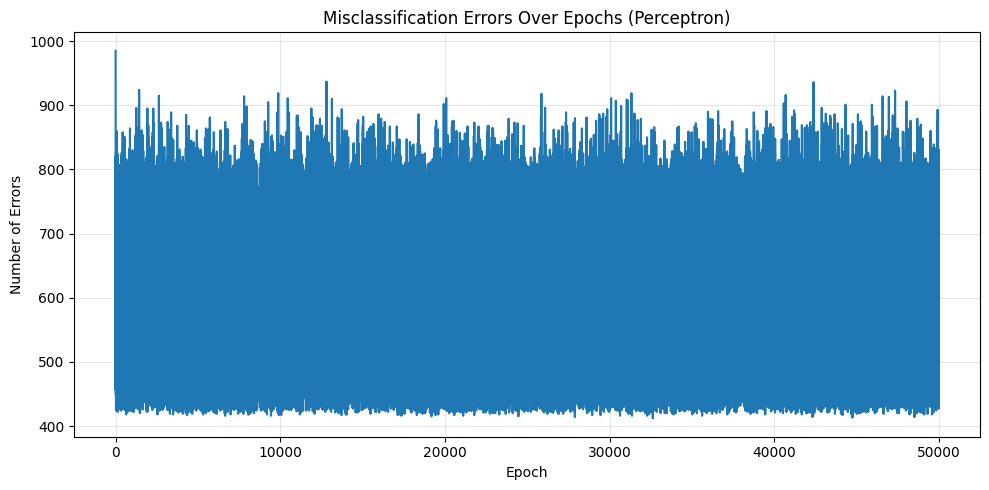

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(perceptron.errors_per_epoch)
plt.title("Misclassification Errors Over Epochs (Perceptron)")
plt.xlabel("Epoch")
plt.ylabel("Number of Errors")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Perceptron — Evaluation on Test Set

In [5]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns

# Predict on test set
y_pred_perceptron = perceptron.predict(X_test)

# Metrics
acc_p = accuracy_score(y_test, y_pred_perceptron)
prec_p = precision_score(y_test, y_pred_perceptron)
rec_p = recall_score(y_test, y_pred_perceptron)
f1_p = f1_score(y_test, y_pred_perceptron)

print("=" * 40)
print("    Perceptron Evaluation Results")
print("=" * 40)
print(f"Accuracy:  {acc_p:.4f}")
print(f"Precision: {prec_p:.4f}")
print(f"Recall:    {rec_p:.4f}")
print(f"F1 Score:  {f1_p:.4f}")
print("=" * 40)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_perceptron, target_names=["No Attrition", "Attrition"]))

    Perceptron Evaluation Results
Accuracy:  0.7465
Precision: 0.7283
Recall:    0.7846
F1 Score:  0.7554

Classification Report:
              precision    recall  f1-score   support

No Attrition       0.77      0.71      0.74       247
   Attrition       0.73      0.78      0.76       246

    accuracy                           0.75       493
   macro avg       0.75      0.75      0.75       493
weighted avg       0.75      0.75      0.75       493



## Perceptron — Confusion Matrix

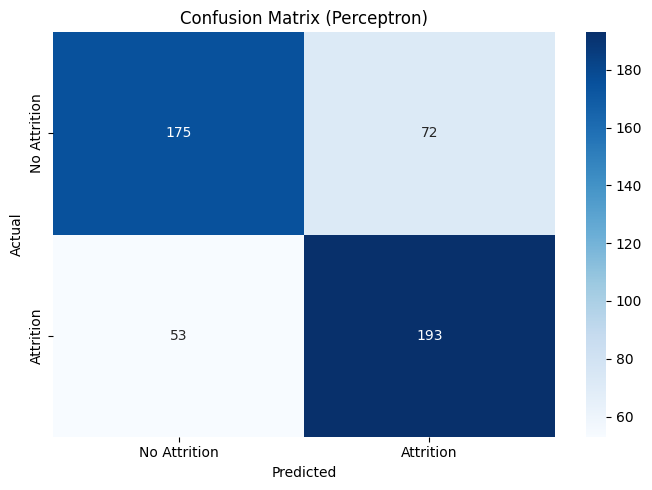

In [6]:
# Confusion Matrix Heatmap
cm_p = confusion_matrix(y_test, y_pred_perceptron)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_p, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Attrition", "Attrition"],
            yticklabels=["No Attrition", "Attrition"])
plt.title("Confusion Matrix (Perceptron)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()